<a href="https://colab.research.google.com/github/Bhawani-Lal/Smartmaintain_Dissertation/blob/main/SmartMaintain_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded")

✅ Libraries loaded


## Load NASA C-MAPSS FD001

In [5]:
# Column names for C-MAPSS dataset

col_names = ['unit_id', 'time_cycles',
             'operational_setting1', 'operational_setting2', 'operational_setting3',
             's1', 's2', 's3', 's4', 's5', 's6', 's7',
             's8', 's9', 's10', 's11', 's12', 's13', 's14',
             's15', 's16', 's17', 's18', 's19', 's20', 's21']

# Load training data
train = pd.read_csv(
    '/content/drive/MyDrive/SmartMaintain_Dataset/train_FD001.txt',
    sep=r'\s+', header=None, names=col_names)

print("Shape:", train.shape)
print("\nFirst 5 rows:")
train.head()

Shape: (20631, 26)

First 5 rows:


,unit_id,time_cycles,operational_setting1,operational_setting2,operational_setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Basic EDA

In [6]:
print("=== BASIC INFO ===")
print(train.info())

print("\n=== MISSING VALUES ===")
print(train.isnull().sum())

print("\n=== STATISTICS ===")
print(train.describe())

print("\n=== NUMBER OF ENGINES ===")
print("Total engine:", train['unit_id'].nunique())

print("\n=== MAX CYCLES PER ENGINE ===")
print(train.groupby('unit_id')['time_cycles'].max().describe())

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   unit_id               20631 non-null  int64  
 1   time_cycles           20631 non-null  int64  
 2   operational_setting1  20631 non-null  float64
 3   operational_setting2  20631 non-null  float64
 4   operational_setting3  20631 non-null  float64
 5   s1                    20631 non-null  float64
 6   s2                    20631 non-null  float64
 7   s3                    20631 non-null  float64
 8   s4                    20631 non-null  float64
 9   s5                    20631 non-null  float64
 10  s6                    20631 non-null  float64
 11  s7                    20631 non-null  float64
 12  s8                    20631 non-null  float64
 13  s9                    20631 non-null  float64
 14  s10                   20631 non-null  float64
 15  

In [8]:
std_values = train.std()
print("Standard Deviation Values:")
print(std_values)
print("\n=== ZERO OR NEAR-ZERO STD (useless sesors) ===")
print(std_values[std_values < 0.001])

Standard Deviation Values:
unit_id                 2.922763e+01
time_cycles             6.888099e+01
operational_setting1    2.187313e-03
operational_setting2    2.930621e-04
operational_setting3    0.000000e+00
s1                      6.537152e-11
s2                      5.000533e-01
s3                      6.131150e+00
s4                      9.000605e+00
s5                      3.394700e-12
s6                      1.388985e-03
s7                      8.850923e-01
s8                      7.098548e-02
s9                      2.208288e+01
s10                     4.660829e-13
s11                     2.670874e-01
s12                     7.375534e-01
s13                     7.191892e-02
s14                     1.907618e+01
s15                     3.750504e-02
s16                     1.556432e-14
s17                     1.548763e+00
s18                     0.000000e+00
s19                     0.000000e+00
s20                     1.807464e-01
s21                     1.082509e-01
RUL        

## Add RUL Column


In [7]:
#Calculation RUL for each engine
#RUL = MAX cycles for that engine - current cycle

rul = train.groupby('unit_id')['time_cycles'].max().reset_index()
rul.columns = ['unit_id', 'max_cycles']

train = train.merge(rul, on='unit_id')
train['RUL'] = train['max_cycles'] - train['time_cycles']
train.drop('max_cycles', axis=1, inplace=True)

print("RUL column added successfully")
print("\nRUL statistics:")
print(train['RUL'].describe().round(2))
print("\nSample with RUL:")
print(train[['unit_id', 'time_cycles', 'RUL']].head(10))

RUL column added successfully

RUL statistics:
count    20631.00
mean       107.81
std         68.88
min          0.00
25%         51.00
50%        103.00
75%        155.00
max        361.00
Name: RUL, dtype: float64

Sample with RUL:
   unit_id  time_cycles  RUL
0        1            1  191
1        1            2  190
2        1            3  189
3        1            4  188
4        1            5  187
5        1            6  186
6        1            7  185
7        1            8  184
8        1            9  183
9        1           10  182


## Drop  Useless Sensors

In [9]:
 # Drop zero variance sesorss
drop_cols = ['operational_setting1', 's1', 's5', 's10', 's16', 's18', 's19']


train = train.drop(columns=drop_cols)
print("✅ Useless sensors dropped")
print("New shape:", train.shape)
print("Remaining columns:", list(train.columns))

✅ Useless sensors dropped
New shape: (20631, 20)
Remaining columns: ['unit_id', 'time_cycles', 'operational_setting2', 'operational_setting3', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']


## Visulaise Sensor Degradation

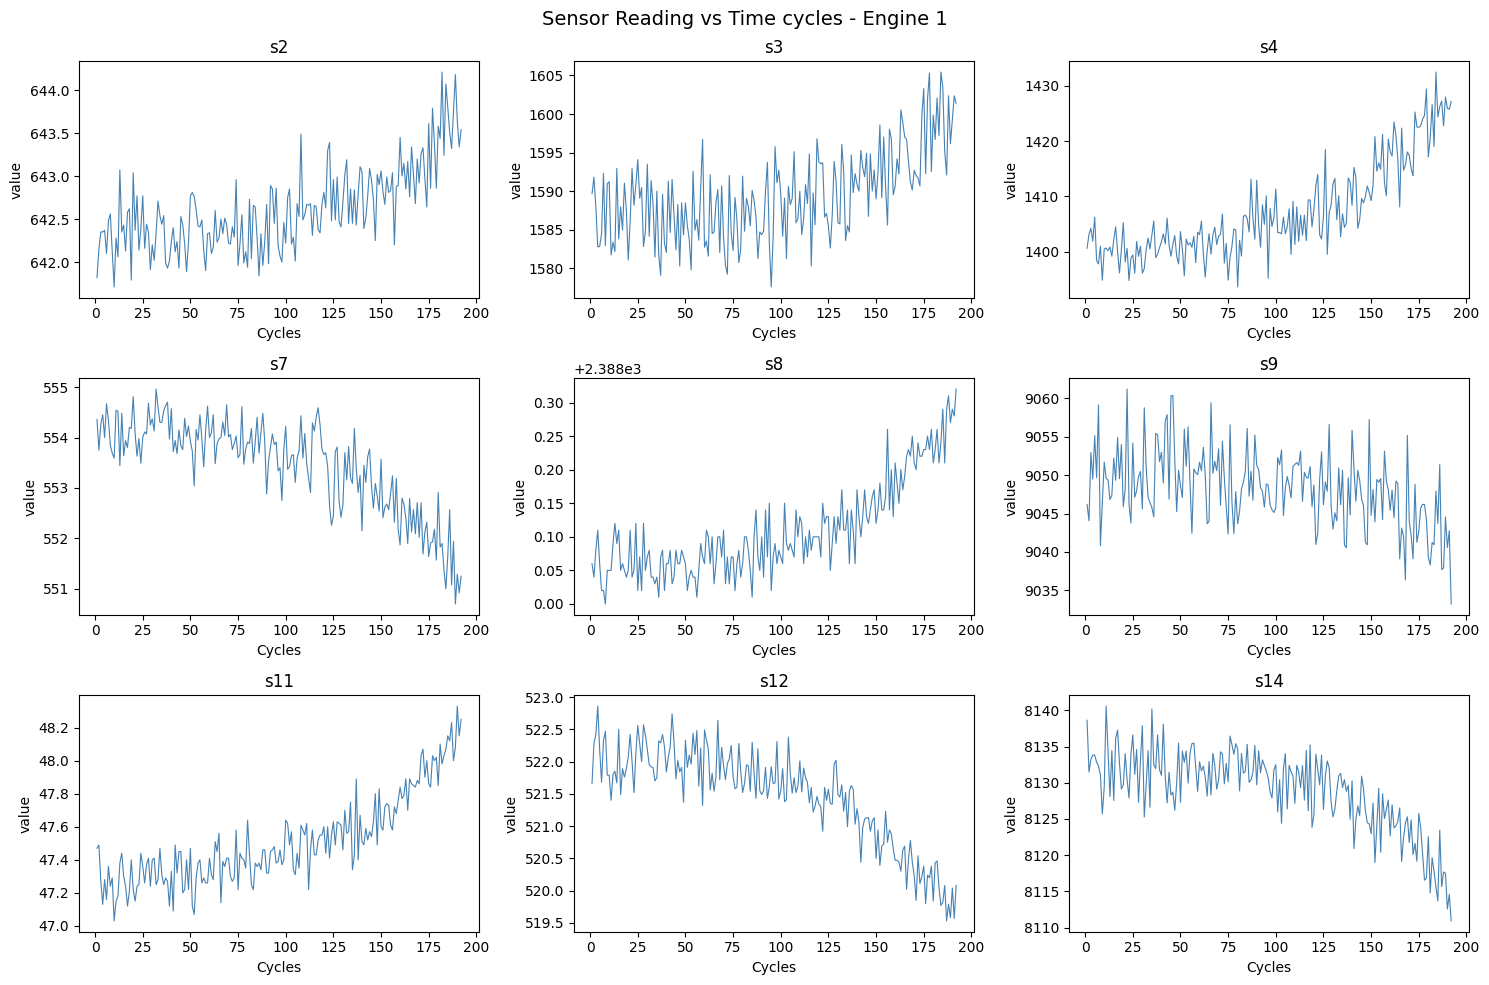

✅ Plot saved


In [12]:
# Plot how sensors change as engine approaches failure
#Using enging 1 as example

engine1 = train[train['unit_id'] == 1].sort_values('time_cycles')

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Sensor Reading vs Time cycles - Engine 1', fontsize=14)

sensors = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's14' ]

for i, sensor in enumerate(sensors):
  ax = axes[i // 3][i%3]
  ax.plot(engine1['time_cycles'], engine1[sensor], color='steelblue', linewidth=0.8)
  ax.set_title(sensor)
  ax.set_xlabel('Cycles')
  ax.set_ylabel('value')

plt.tight_layout()
plt.savefig('sensor_degradation.png', dpi=150)
plt.show()
print('✅ Plot saved')